In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

LANDSCAPE_DIR = '../../examples/comparisons/closed_boundary_DIIID/landscape/coils:3'
LAMBDAS = ['1e-05','1e-06','1e-07','1e-08']
RES = 512

In [ ]:
def lam_path(lam_key):
    return os.path.join(LANDSCAPE_DIR, f'lambda:{lam_key}.npz')

def load_lam(lam_key):
    return np.load(lam_path(lam_key), allow_pickle=True)

data = {lam: load_lam(lam) for lam in LAMBDAS if os.path.exists(lam_path(lam))}
missing = [lam for lam in LAMBDAS if lam not in data]
if missing:
    print(f'missing: {missing}')
for lam, d in data.items():
    print(f'lambda={lam} N={int(d["n_samples"])} min={float(d["min_cost"]):.4e} at (theta2={float(d["min_theta2"]):.2f}, theta3={float(d["min_theta3"]):.2f})')

lambda=1e-05 N=262144 min=3.0643e-02 at (theta2=14.50, theta3=10.00)
lambda=1e-06 N=262144 min=5.5777e-03 at (theta2=10.00, theta3=154.21)
lambda=1e-07 N=262144 min=2.9182e-03 at (theta2=154.74, theta3=10.01)
lambda=1e-08 N=262144 min=2.8874e-03 at (theta2=154.74, theta3=10.01)


In [ ]:
print(data['1e-05'].keys())

data['1e-05']['samples']

KeysView(NpzFile '../../examples/comparisons/closed_boundary_DIIID/landscape/coils:3/lambda:1e-05.npz' with keys: samples, cost, flux_err, theta1_anchor, mu_anchor...)


array([[ 78.9647159 , 140.29887557],
       [163.85260686,  59.82559085],
       [100.32510728, 105.65348879],
       ...,
       [100.32590568,  59.82492223],
       [163.85333374, 105.65289855],
       [ 78.96399319,  14.24203753]], shape=(262144, 2))

In [ ]:
def dedup_topn(samples, costs, n=3, tol_deg=5.0, symmetric=True):
    order = np.argsort(costs)
    s_sorted = samples[order]
    c_sorted = costs[order]
    s_canon = np.sort(s_sorted, axis=1) if symmetric else s_sorted
    kept = [0]
    for i in range(1, len(s_canon)):
        if len(kept) >= n:
            break
        d = np.linalg.norm(s_canon[i] - s_canon[kept], axis=1)
        if d.min() > tol_deg:
            kept.append(i)
    return s_sorted[kept], c_sorted[kept]

In [ ]:
def grid_from_sobol(d, res=RES, method='linear'):
    samples = d['samples']
    cost = d['cost']
    th_lo, th_hi = d['angular_bounds']
    th2_lin = np.linspace(th_lo, th_hi, res)
    th3_lin = np.linspace(th_lo, th_hi, res)
    TH2, TH3 = np.meshgrid(th2_lin, th3_lin, indexing='ij')
    Z = griddata(samples, cost, (TH2, TH3), method=method)
    return th2_lin, th3_lin, Z

def plot_heatmap(ax, d, lam_key, log10=False, cmap='RdBu_r', method='linear', n_points=3, tol_deg=20):
    th2_lin, th3_lin, Z = grid_from_sobol(d, method=method)
    Zp = np.log10(Z) if log10 else Z
    extent = [th2_lin[0], th2_lin[-1], th3_lin[0], th3_lin[-1]]
    im = ax.imshow(Zp.T, origin='lower', extent=extent, aspect='auto', cmap=cmap)
    th1 = float(d['theta1_anchor'])

    top_samples, top_costs = dedup_topn(d['samples'], d['cost'], n=n_points, tol_deg=tol_deg, symmetric=True)

    ax.scatter(top_samples[:, 0], top_samples[:, 1], marker='D', s=80, facecolor='lime', edgecolor='black', linewidth=1.0, zorder=5)
    ax.scatter(top_samples[:, 1], top_samples[:, 0], marker='D', s=80, facecolor='lime', edgecolor='black', linewidth=1.0, zorder=5)
    ax.set_xlabel(r'$\theta_2$ [deg]')
    ax.set_ylabel(r'$\theta_3$ [deg]')
    ax.set_title(
        rf'$\lambda$={lam_key}, $\theta_1$={th1:.0f}$^\circ$, $\mu_1=\mu_2=\mu_3=0$' + '\n' +
        rf'argmin: $\theta_2$={top_samples[0,0]:.1f}$^\circ$, $\theta_3$={top_samples[0,1]:.1f}$^\circ$, $\mathcal{{L}}$={top_costs[0]:.3e}',
        fontsize=10
    )
    return im

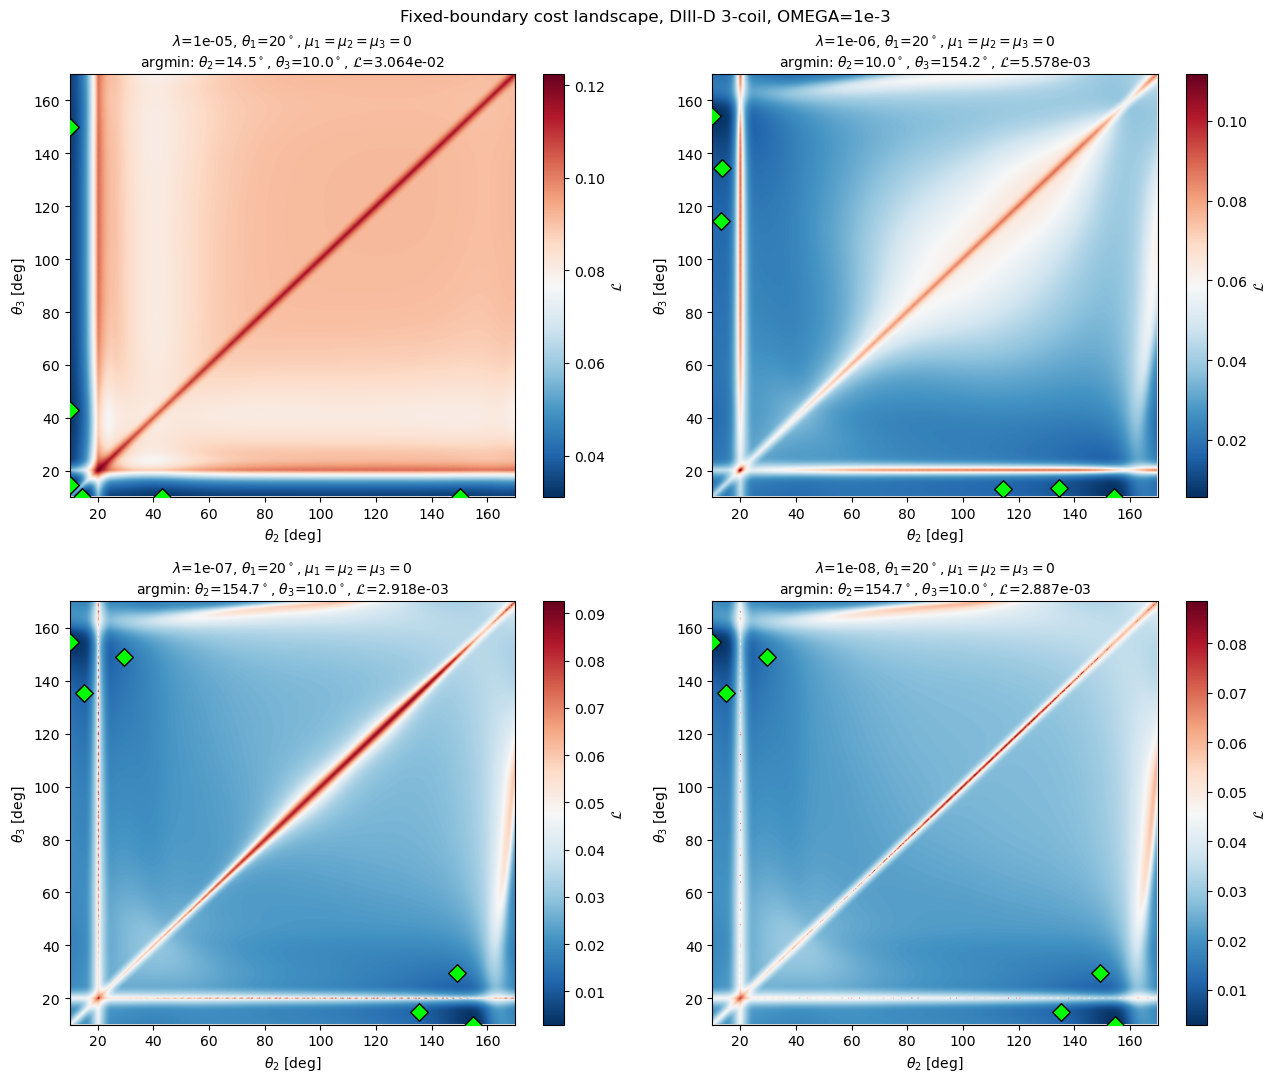

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, lam in zip(axes.flat, LAMBDAS):
    if lam not in data:
        ax.set_visible(False)
        continue
    im = plot_heatmap(ax, data[lam], lam, log10=False)
    plt.colorbar(im, ax=ax, label=r'$\mathcal{L}$')
fig.suptitle('Fixed-boundary cost landscape, DIII-D 3-coil, OMEGA=1e-3', fontsize=12)
fig.tight_layout()
plt.show()

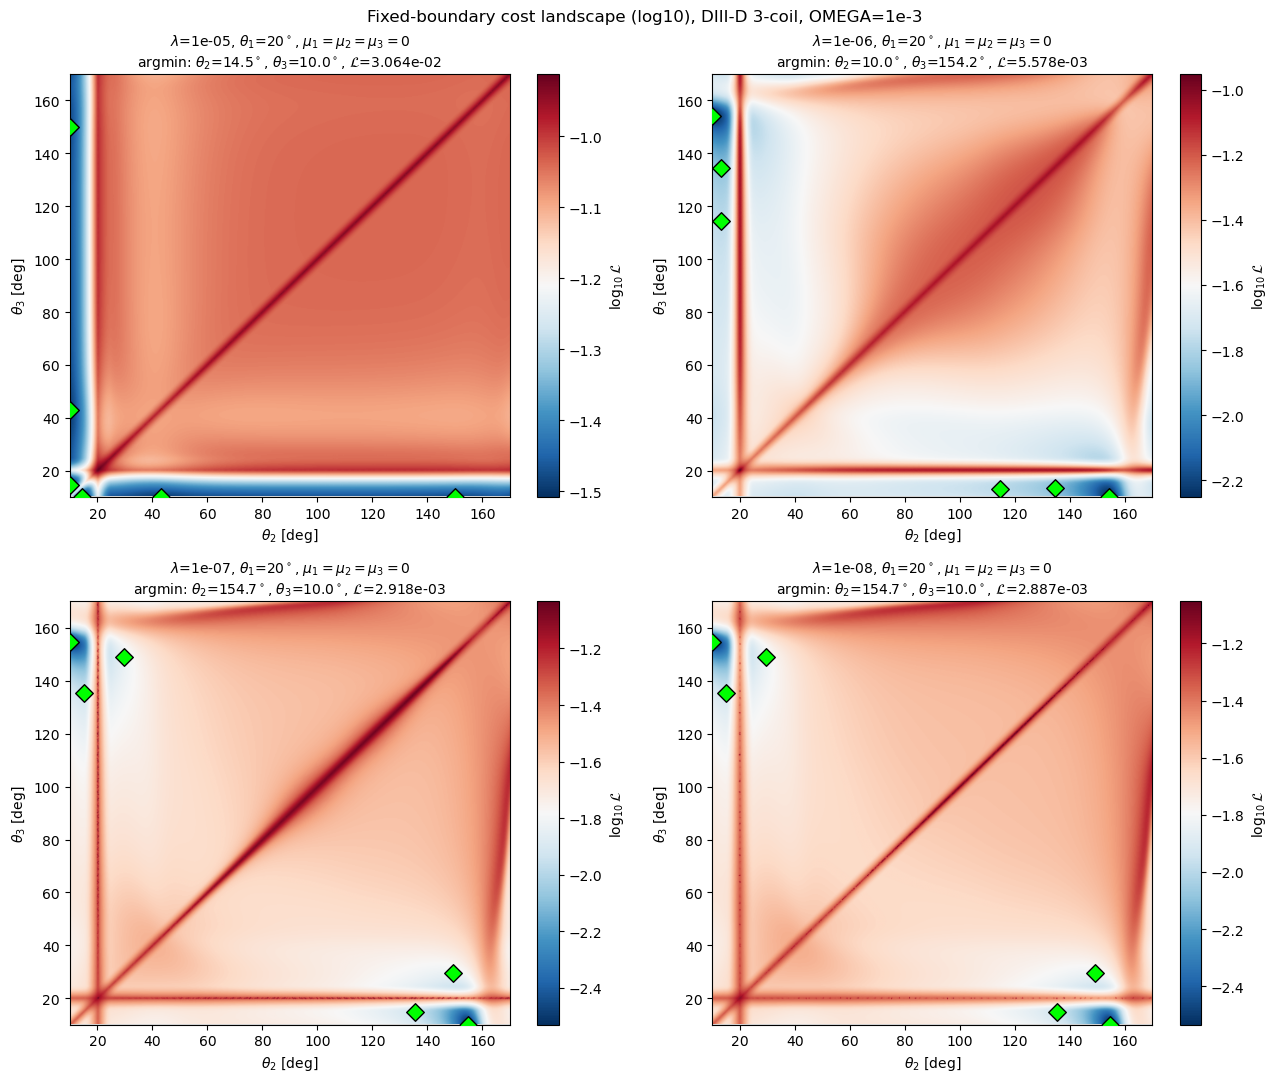

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, lam in zip(axes.flat, LAMBDAS):
    if lam not in data:
        ax.set_visible(False)
        continue
    im = plot_heatmap(ax, data[lam], lam, log10=True)
    plt.colorbar(im, ax=ax, label=r'$\log_{10}\mathcal{L}$')
fig.suptitle('Fixed-boundary cost landscape (log10), DIII-D 3-coil, OMEGA=1e-3', fontsize=12)
fig.tight_layout()
plt.show()

In [ ]:
def plot_slice(ax, d, equation, lam, log10=False, method='linear', show_scatter=False, scatter_tol=0.5):
    samples = d['samples']
    cost = d['cost']
    x = equation['x']
    c = griddata(samples, cost, equation['query'], method=method)
    y = np.log10(c) if log10 else c
    ax.plot(x, y, lw=1.5, color='C0')
    if show_scatter:
        mask = equation['scatter_mask'](samples, scatter_tol)
        sx = equation['scatter_x'](samples[mask])
        sy = cost[mask]
        if log10:
            sy = np.log10(sy)
        ax.scatter(sx, sy, s=3, alpha=1, color='purple', zorder=0)
    th1 = float(d['theta1_anchor'])
    ax.set_xlabel(equation['xlabel'])
    ax.set_ylabel(r'$\log_{10}\mathcal{L}$' if log10 else r'$\mathcal{L}$')
    ax.set_title(rf'$\lambda$={lam}, $\theta_1$={th1:.0f}$^\circ$' + '\n' + equation['desc'], fontsize=10)
    ax.grid(True, alpha=0.3)
    return ax

def build_constant_theta2(d, target, n=512):
    th_lo, th_hi = d['angular_bounds']
    x = np.linspace(th_lo, th_hi, n)
    query = np.column_stack([np.full(n, target), x])
    return {
        'query': query,
        'x': x,
        'xlabel': r'$\theta_3$ [deg]',
        'desc': rf'$\theta_2$={target:.1f}$^\circ$',
        'scatter_mask': lambda s, tol: np.abs(s[:, 0] - target) < tol,
        'scatter_x': lambda s: s[:, 1],
    }

def build_antidiagonal(d, total=170.0, n=512):
    th_lo, th_hi = d['angular_bounds']
    x = np.linspace(th_lo, th_hi, n)
    other = total - x
    mask = (other >= th_lo) & (other <= th_hi)
    x = x[mask]
    query = np.column_stack([x, total - x])
    return {
        'query': query,
        'x': x,
        'xlabel': rf'$\theta_2$ [deg] (with $\theta_3 = {total:.0f} - \theta_2$)',
        'desc': rf'$\theta_2 + \theta_3 = {total:.0f}$',
        'scatter_mask': lambda s, tol: np.abs(s[:, 0] + s[:, 1] - total) < tol,
        'scatter_x': lambda s: s[:, 0],
    }

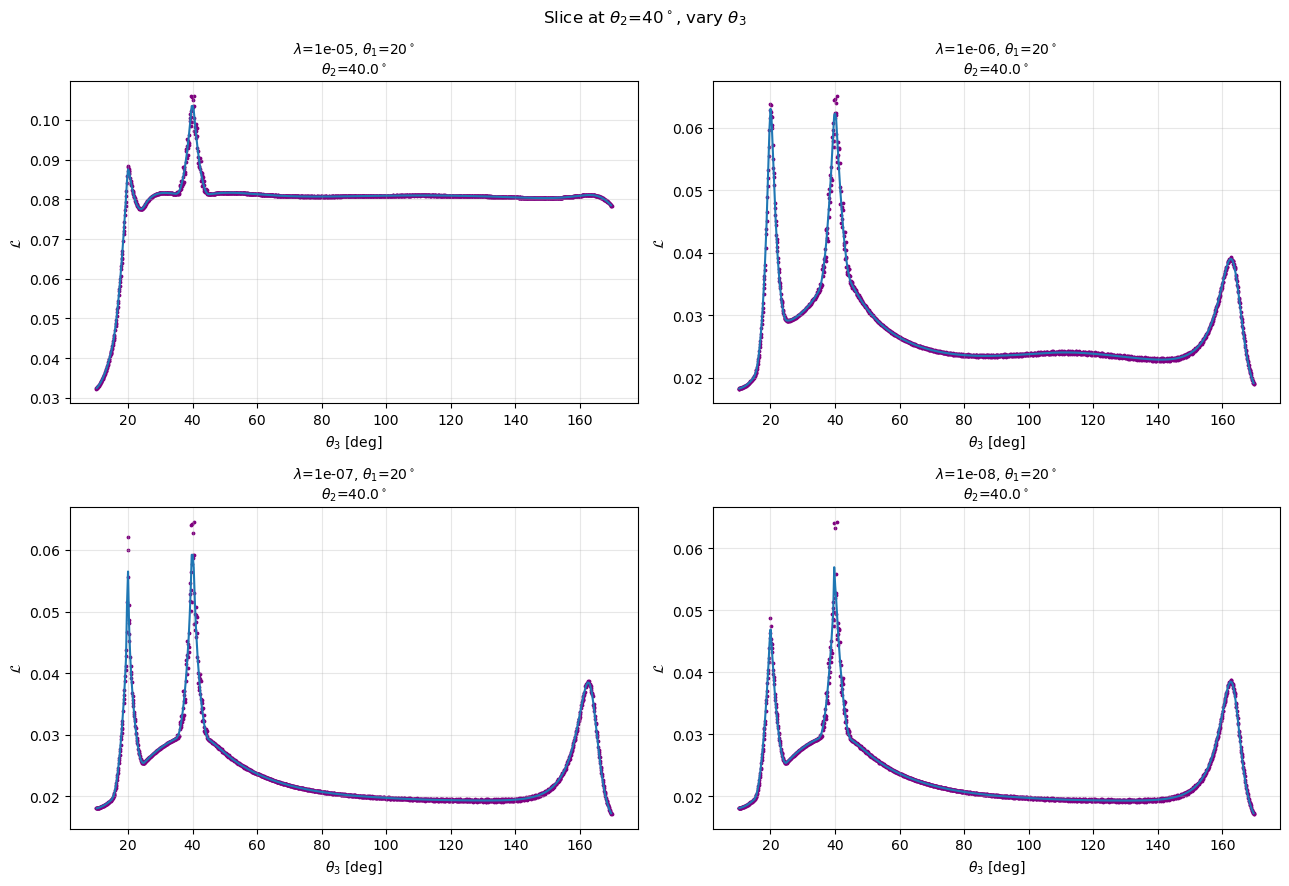

In [ ]:
THETA2_CONST = 40
sample_data = data[next(iter(data))]
constant_theta2_eq = build_constant_theta2(sample_data, target=THETA2_CONST, n=512)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, lam in zip(axes.flat, LAMBDAS):
    if lam not in data:
        ax.set_visible(False)
        continue
    plot_slice(ax, data[lam], constant_theta2_eq, lam, log10=False, show_scatter=True)
fig.suptitle(rf'Slice at $\theta_2$={THETA2_CONST}$^\circ$, vary $\theta_3$', fontsize=12)
fig.tight_layout()
plt.show()

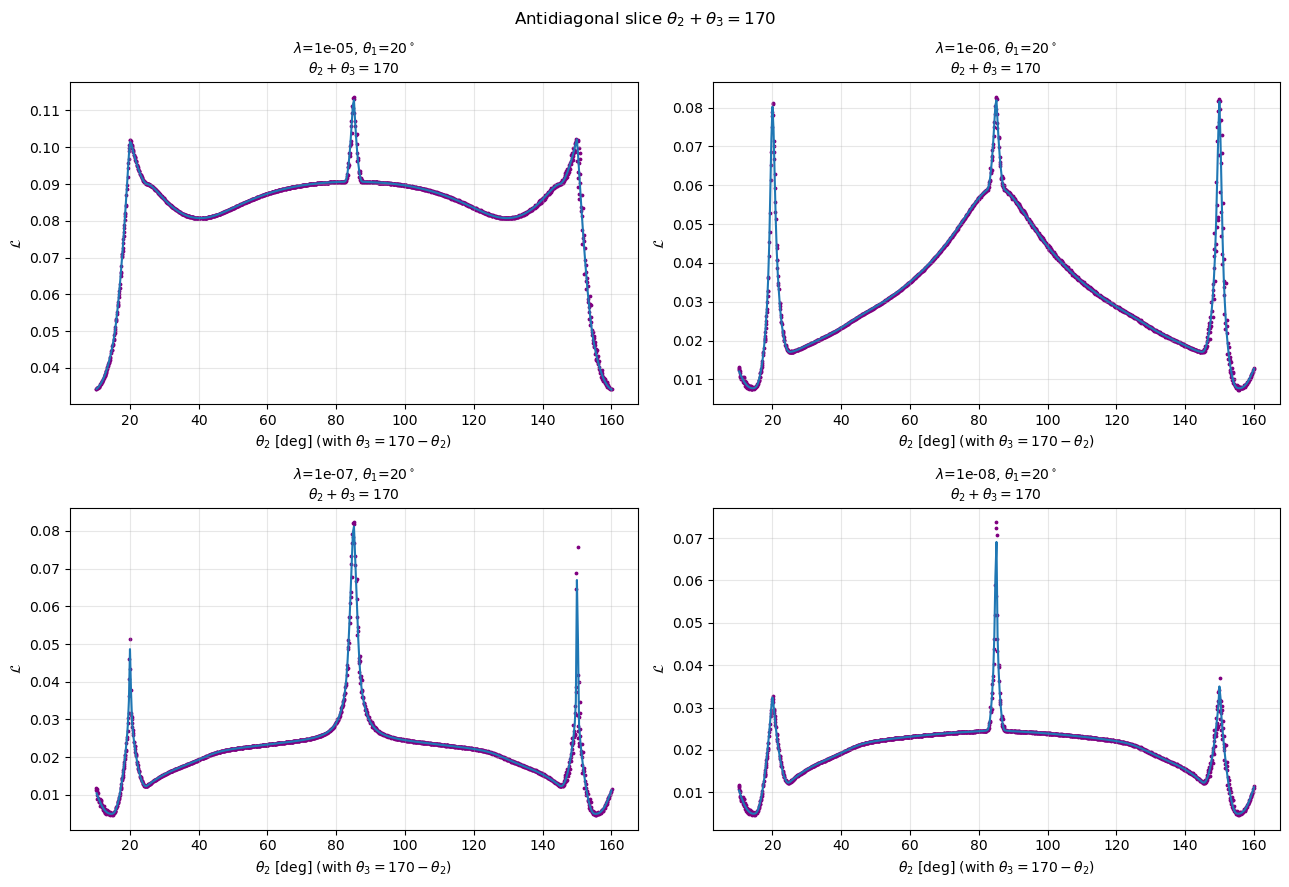

In [ ]:
ANTIDIAG_TOTAL = 170.0
antidiagonal_eq = build_antidiagonal(sample_data, total=ANTIDIAG_TOTAL, n=512)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, lam in zip(axes.flat, LAMBDAS):
    if lam not in data:
        ax.set_visible(False)
        continue
    plot_slice(ax, data[lam], antidiagonal_eq, lam, log10=False, show_scatter=True)
fig.suptitle(rf'Antidiagonal slice $\theta_2 + \theta_3 = {ANTIDIAG_TOTAL:.0f}$', fontsize=12)
fig.tight_layout()
plt.show()